In [1]:
import matplotlib.pyplot as plt
from UHECR_statistics import *
plt.style.use('./allcrs.mplstyle')
from scipy.integrate import cumtrapz

from core import *

colors = [
    '#000000',
    '#252525',
    '#676767',
    '#ffffff',
    '#171723',
    '#004949',
    '#009999',
    '#22cf22',
    '#490092',
    '#006ddb',
    '#b66dff',
    '#ff6db6',
    '#920000',
    '#8f4e00',
    '#db6d00',
    '#ffdf4d',
]

cname = ['cbk', 'cbt', 'cbg', 'cbw', 'cbd', 'cbs', 'cba', 'cbn', 'cbv', 'cbb', 'cbl', 'cbp', 'cbr', 'cbe', 'cbo', 'cby'] 

CB_palette = dict((cn, cl) for cn, cl in zip(cname, colors))

normal parameters: 4.003999999999999e-08 1.3513499999999998e-06 10446205.182602238


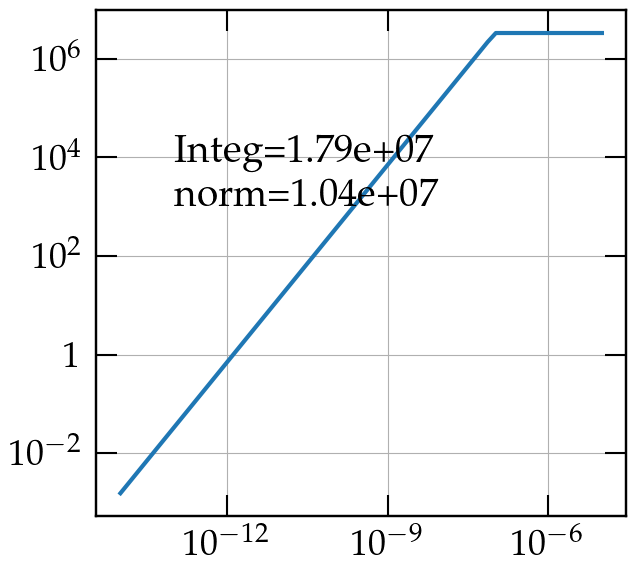

In [2]:
from interaction_rates import *

import os
os.chdir('/home/leonel/')
# physical constants
clight = 3e10  # cm/s (light speed constant)
ergs2GeV = 624.151  # energy conversion factor from ergs to GeV
km2cm = 1e5  # distance conversion factor from km to cm

# TDE parameters
z = .001
f = .1
duration = 1e6 # in seconds
Gamma = 10.  # relativistic Gamma of TDE shell
R = 10**9.6 * km2cm  # cm (radius of interaction of shells)
L = 10**47  # ergs/s

# TDE relations
tvar = (1 + z) * R / 2 / Gamma**2 / clight  # variability time
nos = duration / tvar  # number of shells (in a shell collision picture)
Eiso = ergs2GeV * L * duration / (Gamma * (1 + z))  # GeV
Viso = 4 * np.pi * R**3 / 2 / Gamma  # cm^3
B = np.sqrt(8 * np.pi * Eiso / (ergs2GeV * nos * Viso))  # Magnetic field
# strength Gauss (g^1/2 cm^-1/2 s^-1)

E1 = 4e-7 * (1 + z) / Gamma
E2 = 1.35e-5 * (1 + z) / Gamma
norm = Eiso / nos / Viso
Ebr = 1e-6 * (1 + z) / Gamma
target_photons_TDE = target_photons_spectrum(1e-15, 3e-4, Ebr, 2. / 3, 2,
                                                normal=((E1, E2), norm))
egrid = np.logspace(-14, -5, 60)
plt.loglog(egrid, egrid**2*target_photons_TDE(egrid))
integral = np.trapz(egrid**2 * target_photons_TDE(egrid) * np.log(10), x=np.log10(egrid))
plt.text(1e-13, 1e3, f'Integ={integral:3.2e}\nnorm={norm:3.2e}')
plt.grid()

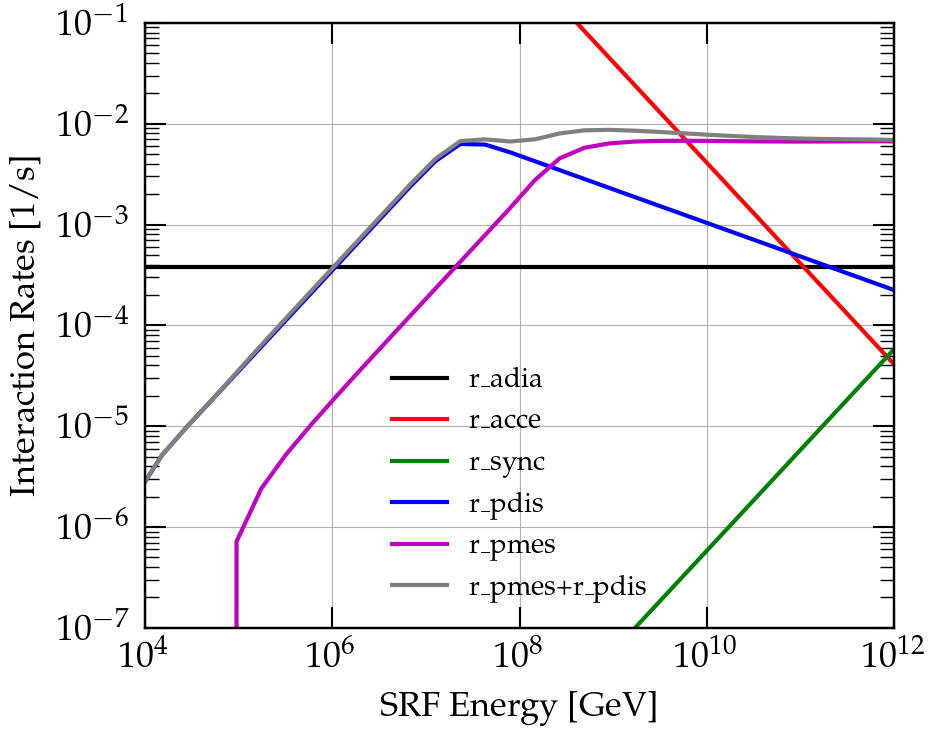

In [3]:
# Calculating interaction rates
SRFenergy = np.logspace(2, 15) / Gamma
r_adia = 1./4*interaction_rate_adiabatic(SRFenergy, R, Gamma)  # adiabatic
r_acce = interaction_rate_acceleration(SRFenergy, 7, 1., B)  # acceleration
r_sync = interaction_rate_synchrotron(SRFenergy, 7, 14, B)  # synchrotron

e = np.linspace(8e-3, .1)  # in GeV
cs = cs_photodisinteg(e, 14, 7)
r_pdis = interaction_rate_from_cross_section(SRFenergy / Gamma, 14,
                                                target_photons_TDE, e, cs)

e = np.logspace(-1, 4, 100)  # in GeV
cs = cs_photomeson(e, 14)  # in cm2
r_pmes = interaction_rate_from_cross_section(SRFenergy / Gamma, 14,
                                                target_photons_TDE, e, cs)

# plotting rates...
plt.subplots(figsize=(10, 8))
plt.plot(SRFenergy, r_adia, c='k', label='r_adia')
plt.plot(SRFenergy, r_acce, c='r', label='r_acce')
plt.plot(SRFenergy, r_sync, c='g', label='r_sync')
plt.plot(SRFenergy, r_pdis, c='b', label='r_pdis')
plt.plot(SRFenergy, r_pmes, c='m', label='r_pmes')
plt.plot(SRFenergy, r_pmes+r_pdis, c='grey', label='r_pmes+r_pdis')

plt.xlabel('SRF Energy [GeV]')
plt.ylabel('Interaction Rates [1/s]')

plt.loglog()
plt.xlim([1e4, 1e12])
plt.ylim([1e-7, 1e-1])
plt.grid()

plt.legend()

In [4]:
from astropy.constants import c
from astropy.units import cm
R / clight # seconds to cross the source
c_in_Mpc_sec = c.to('Mpc/s').value

R_Mpc = R*cm.to('Mpc')
nominal_rate = 0.01
unit_radius = R_Mpc/Gamma
print(f'The radius of the blob is {R_Mpc:3.2e} Mpc')
print(f'The light crossing time is {R/clight:3.2e} s')
print(f'The number of interactions for a rate of {nominal_rate:3.2e} 1/s is {nominal_rate * R / clight:3.2e} interactions.')

The radius of the blob is 1.29e-10 Mpc
The light crossing time is 1.33e+04 s
The number of interactions for a rate of 1.00e-02 1/s is 1.33e+02 interactions.


---
# Source studies

In [5]:
so = InteractionCore_UHECR_Source('/home/leonel/GitProjects/CRPropa3-data/tables/PD_Talys1.8_Khan/', target_photons_TDE)

(0.1, 10)

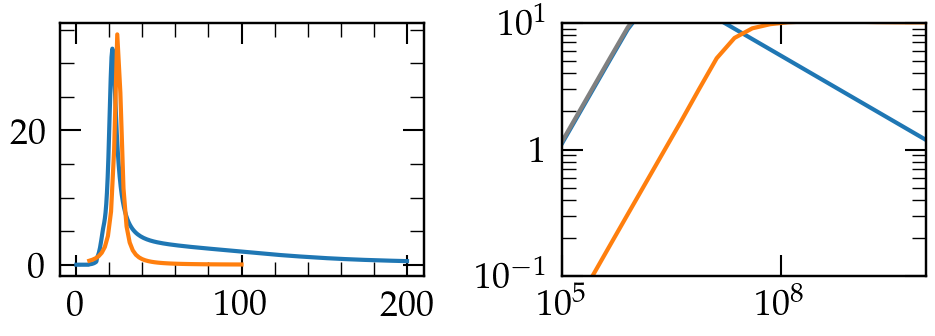

In [6]:
e_vals = np.genfromtxt('/home/leonel/GitProjects/CRPropa3-data/tables/PD_Talys1.8_Khan/eps.txt')
cs_vals = np.genfromtxt('/home/leonel/GitProjects/CRPropa3-data/tables/PD_Talys1.8_Khan/xs_pd_sum.txt')

idx = 22
f, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.sca(axes[0])
plt.plot(e_vals, cs_vals[idx, 2:])
plt.plot(np.linspace(8e-3, .1)*1e3, cs_photodisinteg(np.linspace(8e-3, .1), cs_vals[idx][0]+cs_vals[idx][1], cs_vals[idx][0])*1e27)

plt.sca(axes[1])

mb_to_cm2 = 1e-27
A = np.sum(cs_vals[22, :2])
pdis_rate_crpropa = interaction_rate_from_cross_section(A*np.logspace(0, 12), A, target_photons_TDE, e_vals/1e3, cs_vals[idx, 2:]*mb_to_cm2) / c_in_Mpc_sec # 1/Mpc
plt.loglog(np.logspace(1, 13), pdis_rate_crpropa*unit_radius)

e_pmes = np.logspace(-1, 4, 100)  # in GeV
cs_pmes = cs_photomeson(e_pmes, A) # in cm2
pmes_rate_crpropa = interaction_rate_from_cross_section(A*np.logspace(0, 12), A, target_photons_TDE, e_pmes, cs_pmes) / c_in_Mpc_sec # 1/Mpc
plt.loglog(np.logspace(1, 13), pmes_rate_crpropa*unit_radius)

plt.plot(np.logspace(1, 13), (pdis_rate_crpropa+pmes_rate_crpropa)*unit_radius, c='grey')

plt.xlim(1e5, 1e10)
# plt.ylim(1e10, 1e13)
plt.ylim(1e-1, 10)


(10000.0, 200000000000.0)

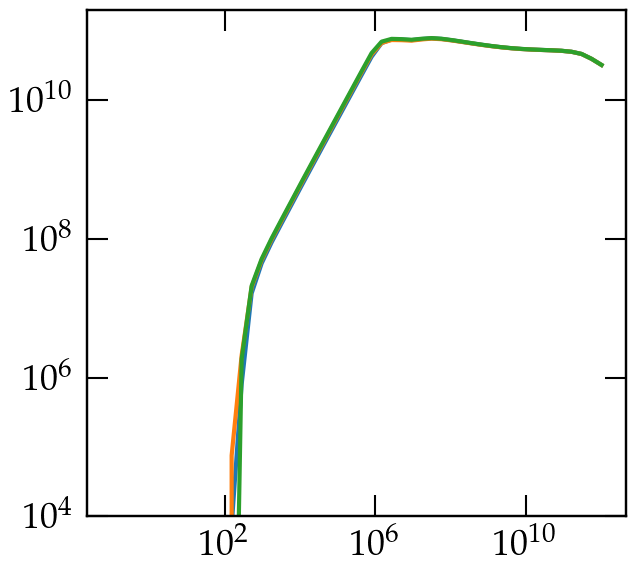

In [7]:
so.nuclei
plt.loglog(so.boosts, so.all_rates[10] / so.nuclei[10][-1])
plt.loglog(so.boosts, so.all_rates[100] / so.nuclei[100][-1])
plt.loglog(so.boosts, so.all_rates[150] / so.nuclei[150][-1])
plt.ylim(1e4, 2e11)

Using boost 7.74e+09


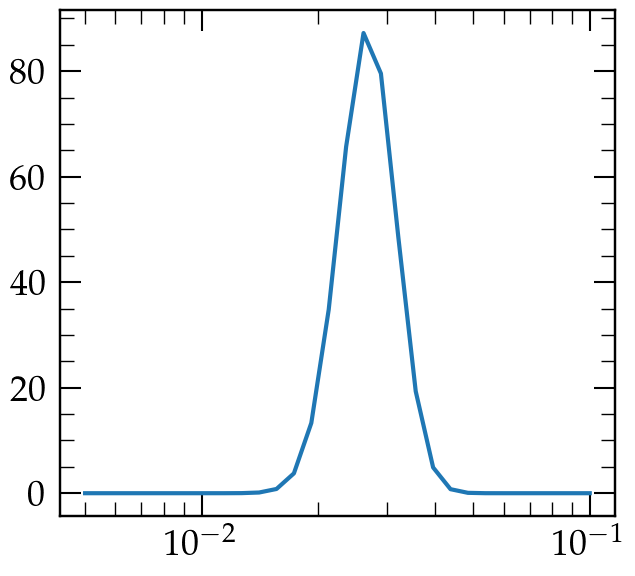

In [8]:
br = np.logspace(9, 10, 10)
distances = np.logspace(-11.3, -10, 30) # MpC
boostidx = 8
print(f'Using boost {br[boostidx]:3.2e}')

alpha, mr = get_injection_parameters(so.species, (56, 12), ('flat', [56]))
alpha[:] = 0
alpha[0] = 1
boosts, total = so.pdf_boost_range(distances, alpha, mass_range=mr, boost_range=br)
factor = 1e9 # Mpc to mpc
plt.semilogx(distances*factor, 1/factor*total[boostidx, :])


### Distributions with multiple absorption states

In [9]:
def get_injection_parameters_correct(species, mass_lims=(56, 11), injection_type=('flat', None)):
    """Produces the injection vector and mass_range required to
    produce the distribution of nuclei starting from a certain mass
    and producing mass lower than a minimum given value.

    Arguments:
    ----------
    species : The list of species (Z, A) that are included in the full nuclear cascade.
    mass_lims : a tuple (Amax, Amin) with the starting mass and the lower limit for mass
    injection type : (type, params) (str, dict) info specifying the injection. Possible values
                - 'flat' : equal injection of all species included within the mass range mass_lims
                - 'only mass' : equal injection of all species specified by a mass value in a list
                - 'only species' : equal injection of all species specified as (Z, A)
    """
    Amax, Amin = mass_lims

    common_mass_range = np.array([k for k, spec in enumerate(species) if Amax >= spec[1] > Amin])
    ending_species = np.array([k for k, spec in enumerate(species) if Amin == spec[1]])

    mass_ranges = []
    for es in ending_species:
        # make the list of species ending in each ending species
        mass_ranges.append(np.hstack([common_mass_range, es]))
    
    alpha = np.ones(len(mass_ranges[0]))

    itype, params = injection_type

    # if itype == 'flat':
    #     alpha /= sum(alpha)
    # elif itype == 'only mass':
    #     masses = range(*mass_lims)
    #     indices = np.array([k for k, idx in enumerate(mass_range) if species[idx][1] not in masses])
    #     alpha[indices] = 0
    #     alpha /= sum(alpha)
    # elif itype == 'only species':
    #     species = params
    #     indices = np.array([k for k, idx in enumerate(mass_range) if species[idx] != species])
    #     alpha[indices] = 0
    #     alpha /= sum(alpha)

    return alpha, mass_ranges

def get_single_absorption_matrices(boostidx, species, mass_lims=(56, 11), injection_type=('flat', None)):
    """Returns the matrices corresponding to single absorption states for each of the ending
    states (each of the species with mass Amin)

    Arguments:
    ----------
    species : The list of species (Z, A) that are included in the full nuclear cascade.
    mass_lims : a tuple (Amax, Amin) with the starting mass and the lower limit for mass
    injection type : (type, params) (str, dict) info specifying the injection. Possible values
                - 'flat' : equal injection of all species included within the mass range mass_lims
                - 'only mass' : equal injection of all species specified by a mass value in a list
                - 'only species' : equal injection of all species specified as (Z, A)
    """
    _, mrs = get_injection_parameters_correct(species, mass_lims, injection_type)

    all_mats = []
    # correcting matrices
    for mr in mrs:
        temp_mat = so.tensor[np.ix_(mr, mr, [boostidx])][:, :, 0]
        sel_rows = temp_mat.sum(axis=1) != np.diag(temp_mat)
        sel_rows[-1] = True # last row is the absorbing state

        mat = so.tensor[np.ix_(mr, mr, [boostidx])][:, :, 0][np.ix_(sel_rows, sel_rows)]
        rem = np.diag(mat.dot(np.ones(len(mat))))
        rem[-1, -1] = 0
        mat -= rem

        all_mats.append(mat)
    
    return all_mats

In [ ]:
get_single_absorption_matrices(38, so.species, (56, 54), ('flat', [56]))

In [10]:
[mat1, mat2, mat3] = get_single_absorption_matrices(38, so.species, (56, 54), ('flat', [56]))

In [11]:
alpha, mrs = get_injection_parameters_correct(so.species, (56, 54), ('flat', [56]))
boostidx = 38

i=2
print(so.tensor[np.ix_(mrs[i], mrs[i], [boostidx])][:, :, 0])

idxs = [0, 1, 3]
mat1 = so.tensor[np.ix_(mrs[0], mrs[0], [boostidx])][:, :, 0][np.ix_(idxs, idxs)]
rem = np.diag(mat1.dot(np.ones(3)))
rem[-1, -1] = 0
mat1 -= rem

mat2 = so.tensor[np.ix_(mrs[1], mrs[1], [boostidx])][:, :, 0]
rem = np.diag(mat2.dot(np.ones(4)))
rem[-1, -1] = 0
mat2 -= rem

idxs = [0, 2, 3]
mat3 = so.tensor[np.ix_(mrs[2], mrs[2], [boostidx])][:, :, 0][np.ix_(idxs, idxs)]
rem = np.diag(mat3.dot(np.ones(3)))
rem[-1, -1] = 0
mat3 -= rem


br = np.logspace(np.log10(so.boosts[38])-2, np.log10(so.boosts[38])+2, 5)
alpha, mr = get_injection_parameters(so.species, (56, 54), ('flat', [56]))
distances2 = np.logspace(-40, -37, 100) # MpC
boostidx = 2
print(f'Using boost {br[boostidx]:3.2e}')
boosts, total = so.pdf_boost_range(distances2, alpha, mass_range=mr, boost_range=br)

[[-3.41311883e+12  1.82845652e+12  1.58466231e+12  0.00000000e+00]
 [ 0.00000000e+00 -3.35280048e+12  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -3.20526721e+12  1.45693964e+12]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.28889442e+12]]
Using boost 1.21e+09


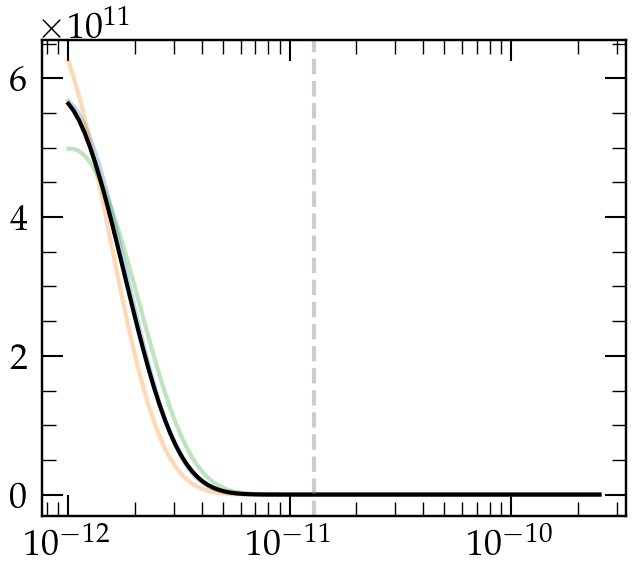

In [12]:
distances = np.logspace(-12, -9.6, 100) # MpC
plt.semilogx(distances, pdf(distances, mat1), alpha=.3)
plt.semilogx(distances, pdf(distances, mat2), alpha=.3)
plt.semilogx(distances, pdf(distances, mat3), alpha=.3)

tot = np.vstack([pdf(distances, mat) for mat in [mat1, mat2, mat3]]).mean(axis=0)

plt.semilogx(distances, tot, c='k')
# plt.semilogx(distances, total[2, :])

plt.axvline(R_Mpc/Gamma, c='grey', ls='--', alpha=.4)

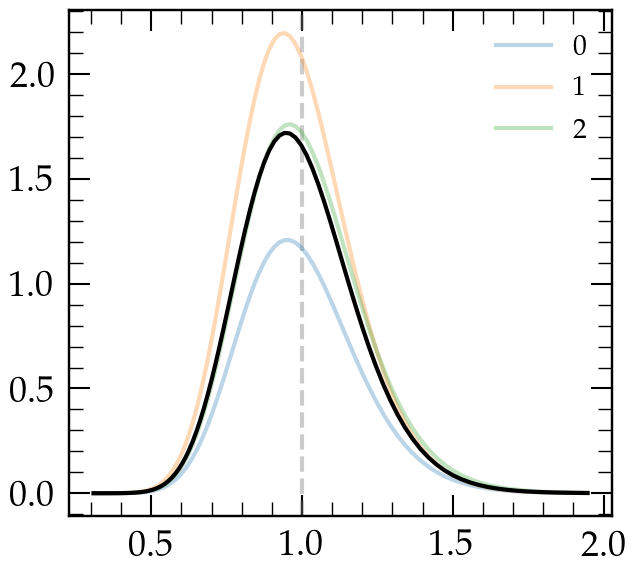

In [13]:
all_mats = get_single_absorption_matrices(35, so.species, (56, 25), ('flat', [56]))
distances = np.logspace(-11.4, -10.6, 100) # MpC

unit_radius = R_Mpc/Gamma
plt.axvline(1, c='grey', ls='--', alpha=.4)

tot = np.zeros_like(distances)
for k, mat in enumerate(all_mats):
    subpdf = pdf(distances, mat)
    plt.plot(distances/unit_radius, unit_radius * subpdf, alpha=.3, label=k)

    tot += subpdf
tot /= (k+1)

plt.plot(distances/unit_radius, unit_radius * tot, c='k')
# plt.semilogx(distances, total[2, :])
plt.legend()

---

# ICRC plots

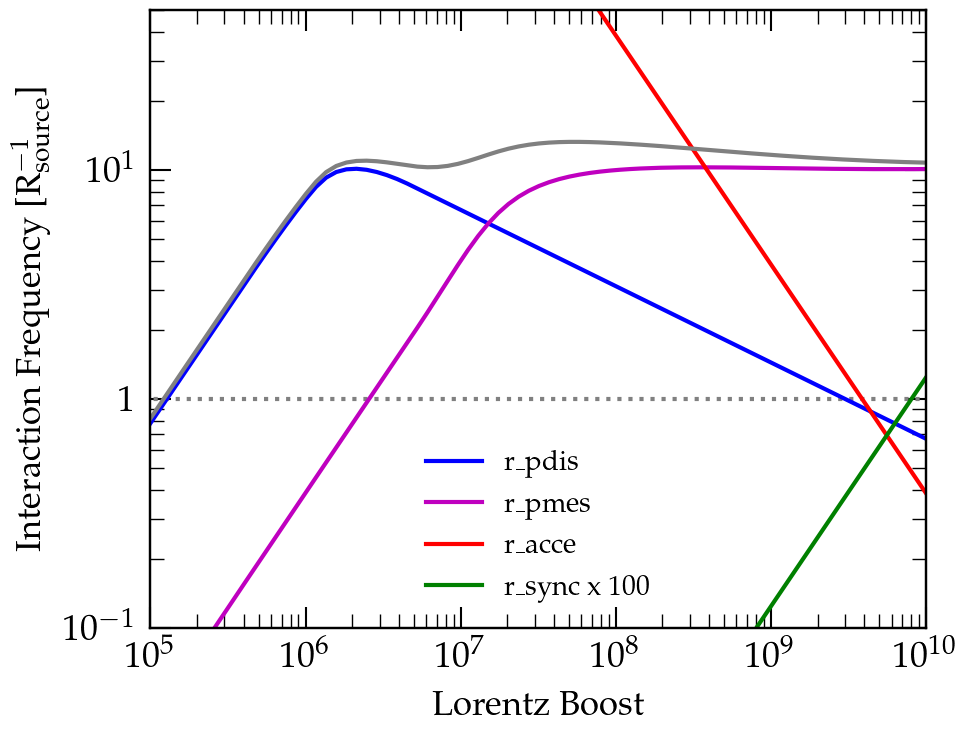

In [21]:
Z, A = 8, 16
# Calculating interaction rates
SRFenergy = np.logspace(2, 15, 200) / Gamma
r_adia = 1./2*interaction_rate_adiabatic(SRFenergy, R, Gamma)  # adiabatic
r_acce = interaction_rate_acceleration(SRFenergy, Z, 1., B)  # acceleration
r_sync = interaction_rate_synchrotron(SRFenergy, Z, A, B)  # synchrotron

e = np.linspace(8e-3, .1)  # in GeV
cs = cs_photodisinteg(e, A, Z)
r_pdis = interaction_rate_from_cross_section(SRFenergy / Gamma, A,
                                                target_photons_TDE, e, cs)

e = np.logspace(-1, 4, 100)  # in GeV
cs = cs_photomeson(e, A)  # in cm2
r_pmes = interaction_rate_from_cross_section(SRFenergy / Gamma, A,
                                                target_photons_TDE, e, cs)

# plotting rates...
plt.subplots(figsize=(10, 8))
plt.plot(SRFenergy/A, np.ones_like(r_adia), c='grey', ls=':')
plt.plot(SRFenergy/A, r_pdis/r_adia, c='b', label='r_pdis')
# plt.plot(np.logspace(1, 13), pdis_rate_crpropa*unit_radius, c=CB_palette['cbl'], label='r_pdis')
plt.plot(SRFenergy/A, r_pmes/r_adia, c='m', label='r_pmes')
plt.plot(SRFenergy/A, r_acce/r_adia, c='r', label='r_acce')
plt.plot(SRFenergy/A, 1e2*r_sync/r_adia, c='g', label='r_sync x 100')
plt.plot(SRFenergy/A, r_pmes/r_adia + r_pdis/r_adia, c='grey')

plt.xlabel('Lorentz Boost')
plt.ylabel(r'Interaction Frequency [R$^{-1}_{\rm{source}}$]')

plt.loglog()
plt.xlim([1e5, 1e10])
plt.ylim([1e-1, 5e1])
# plt.grid()

plt.legend()

In [15]:
blist=[5e4, 6e4, 7e4, 1e5, 2e5, 2e6]
for boost, ls in zip(blist, ['-.', '--', '-', ':']):
    boostidx = np.argwhere(so.boosts <= boost)[-1][0]
    for c, Amin in zip(colors, [13, ]):
        bs, tots = [], []
        for bi in range(boostidx-4, boostidx+6):
            all_mats = get_single_absorption_matrices(bi, so.species, (A, Amin), ('flat', [A]))

            bs.append(so.boosts[bi])
            tots.append(np.vstack([pdf(distances, mat) for mat in all_mats]).mean(axis=0))
        
        tot = interp1d(bs, np.vstack(tots).T, 'cubic')

        plt.plot(distances/D, D * tot(boost), label=f'{boost:1.0e}', ls=ls, c=c)

        p_upto_R = np.interp(1, distances/D, cumtrapz(D * tot(boost), distances/D, initial=0))
        print(f'At boost {boost:1.0e} and Amin {Amin:2d} the probability inside the source is {p_upto_R:3.3f}')

axes[0].set_xticks(np.logspace(5, 10, 6))
plt.xlabel(r'Distance / D$_{\rm{source}}$')
plt.ylabel('Probability density')

NameError: name 'D' is not defined

[array([[-2.72136956,  0.        ,  0.        ,  1.36068478,  1.36068478,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -1.96527339,  0.        ,  0.        ,  1.10546628,
         0.85980711,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.86941341,  0.        ,  0.        ,
         1.86941341,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -1.79423331,  0.        ,
         0.        ,  0.83730888,  0.95692443,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -1.77033989,
         0.        ,  0.        ,  0.94418128,  0.82615862,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -1.74786422, 

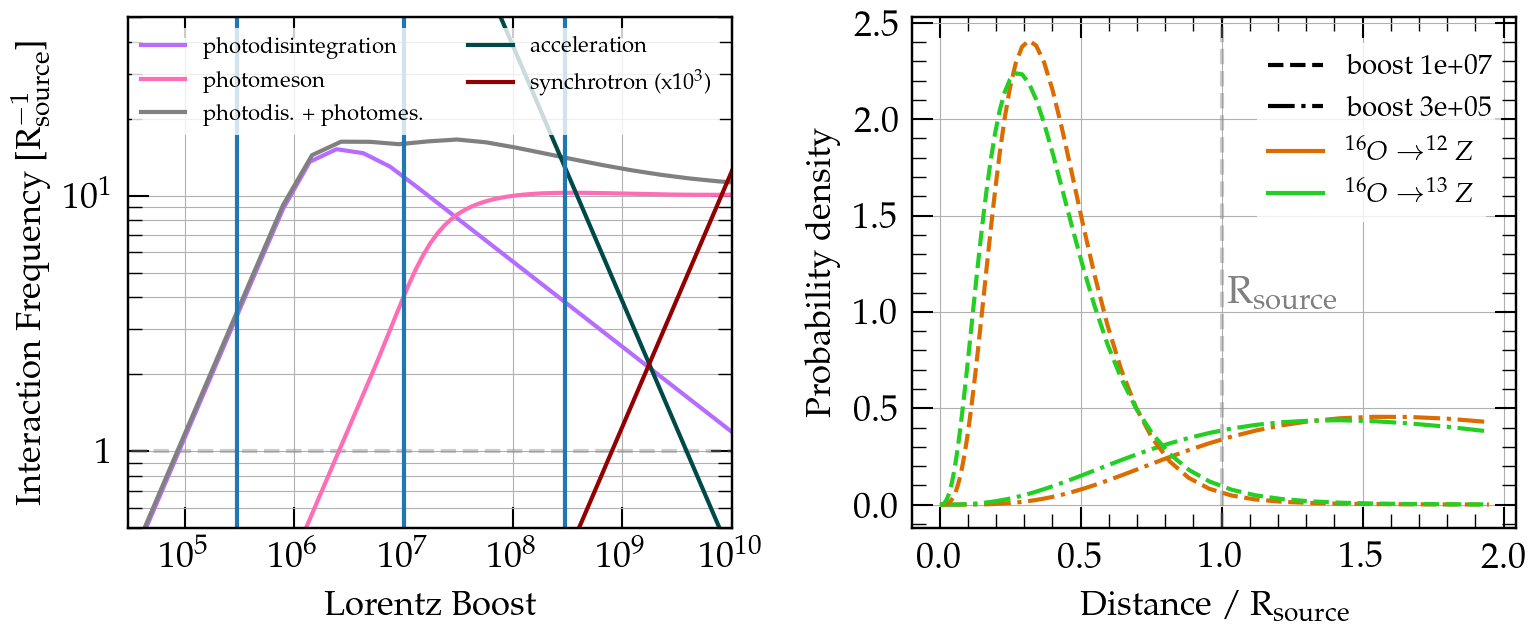

In [103]:
from scipy.interpolate import interp1d

f, axes = plt.subplots(1, 2, figsize=(16, 7))
# plotting rates...
plt.sca(axes[0])
plt.plot(SRFenergy/A, np.ones_like(r_adia), c='grey', ls='--', alpha=.4)
# plt.plot(SRFenergy/A, r_pdis/r_adia, c=CB_palette['cbl'], label='r_pdis')
plt.plot(np.logspace(1, 13), pdis_rate_crpropa*c_in_Mpc_sec/r_adia[0], c=CB_palette['cbl'], label='r_pdis')
plt.plot(SRFenergy/A, r_pmes/r_adia, c=CB_palette['cbp'], label='r_pmes')
# plt.plot(SRFenergy/A, r_pmes/r_adia + r_pdis/r_adia, c='k', label='sum', ls=':')
plt.loglog(so.boosts, -so.tensor[157, 157, :]*c_in_Mpc_sec/r_adia[0], c='grey', label='sum')
plt.plot(SRFenergy/A, r_acce/r_adia, c=CB_palette['cbs'], label='r_acce')
plt.plot(SRFenergy/A, 1e3*r_sync/r_adia, c=CB_palette['cbr'], label='r_sync x 1000')

plt.xlabel('Lorentz Boost')
plt.ylabel(r'Interaction Frequency [R$^{-1}_{\rm{source}}$]')

plt.loglog()

plt.xlim([3e4, 3e9])
plt.ylim([5e-1, 5e1])
han, _ = axes[0].get_legend_handles_labels()
plt.legend(han, ['photodisintegration', 'photomeson', 'photodis. + photomes.', 'acceleration', r'synchrotron (x$10^3$)'], ncol=2, frameon=True, edgecolor='none', fontsize=16)
# plt.legend()

# ------------------------
colors = [CB_palette['cbo'], CB_palette['cbn']]
distances = np.logspace(-14, -10.4, 100) # MpC
distances = np.logspace(-14, -10.6, 100) # MpC
unit_radius = 1/r_adia[0] * c_in_Mpc_sec
D = unit_radius

plt.sca(axes[1])
blist=[3e5, 1e7]
for boost, ls in zip(blist, ['-.', '--']):
    boostidx = np.argwhere(so.boosts <= boost)[-1][0]
    for c, Amin in zip(colors, [12, 13]):
        bs, tots = [], []
        for bi in range(boostidx-4, boostidx+6):
            all_mats = get_single_absorption_matrices(bi, so.species, (A, Amin), ('flat', [A]))
            
            # if bi == boostidx:
            #     print([m*c_in_Mpc_sec/r_adia[0] for m in all_mats])

            bs.append(so.boosts[bi])
            tots.append(np.vstack([pdf(distances, mat) for mat in all_mats]).mean(axis=0))
        
        tot = interp1d(bs, np.vstack(tots).T, 'cubic')

        # all_mats = get_single_absorption_matrices(boostidx, so.species, (A, Amin), ('flat', [A]))
        # tot = np.vstack([pdf(distances, mat) for mat in all_mats]).mean(axis=0)
        # plt.plot(distances/D, D * tot, label=f'{so.boosts[boostidx]:1.0e}', ls=ls, c=c)
        # p_upto_R = np.interp(1, distances/D, cumtrapz(D * tot, distances/D, initial=0))

        plt.plot(distances/D, D * tot(boost), label=f'{boost:1.0e}', ls=ls, c=c)
        # plt.plot(distances/D, cumtrapz(D * tot(boost), distances/D, initial=0), ls=ls, c=c)
        p_upto_R = np.interp(D, distances, cumtrapz(tot(boost), distances, initial=0))
        # rate_at_boost = 
        print(f'At boost {boost:1.0e} and Amin {Amin:2d} the probability inside the source is {p_upto_R:3.3f} and the interaction rate is {10:2.1f}')

axes[0].set_xticks(np.logspace(5, 10, 6))
plt.xlabel(r'Distance / R$_{\rm{source}}$')
plt.ylabel('Probability density')

plt.plot([], [], ls='--', c='k', label='somelab')
plt.plot([], [], ls='-.', c='k', label='somelab')
plt.plot([], [], ls='-', c=colors[0], label='somelab')
plt.plot([], [], ls='-', c=colors[1], label='somelab')
handles, labels = plt.gca().get_legend_handles_labels()
l1 = plt.legend(handles[6:], ['$^{16}O \\to ^{12}Z$', '$^{16}O \\to ^{13}Z$'], loc=(.57, .6), frameon=True, edgecolor='none')
plt.legend(handles[4:], ['boost '+labels[2], 'boost '+labels[0]], loc=(.57, .77), frameon=True, edgecolor='none')
plt.gca().add_artist(l1)

# axes[0].text(1.1e7, 1.2, r'R$^{-1}_{\rm{source}}$', c='grey')
axes[1].text(1.02, 1.04, r'R$_{\rm{source}}$', c='grey')
axes[1].axvline(1, c='grey', ls='--', alpha=.4)

# ---- testing ----
for bi in blist:
    axes[0].axvline(bi)
axes[0].axvline(3e8)
axes[0].grid(which='both')
axes[1].grid()
# axes[0].loglog(so.boosts*10, -so.tensor[157, 157, :]*unit_radius/2, c='k', ls='-.')

plt.savefig('pdf_source_example.pdf', dpi=300, bbox_inches='tight')

In [ ]:
so.species[157]

(8, 16)

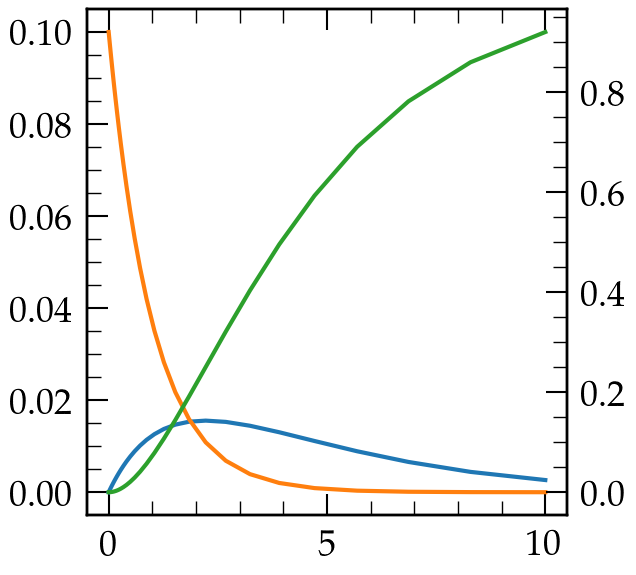

In [93]:
dvals = np.logspace(-2, 2.)
matvals = np.array([
    [-1, .6, .4, 0],
    [0, -.9, .4, .5],
    [0,  0, -1, 1],
    [0, 0, 0, -.5],
])

matvals = np.array([
    [-.1, .05, .05],
    [0, -.04, .04],
    [0,  0, -.04]
])

plt.plot(-matvals[0, 0]*dvals, pdf(dvals, matvals))
plt.plot(-matvals[0, 0]*dvals, -matvals[0, 0]*np.exp(matvals[0, 0]*dvals))

ax2 = plt.twinx()
plt.plot(-matvals[0, 0]*dvals, cumtrapz(pdf(dvals, matvals), dvals, initial=0), c='C2')